In [ ]:
# Imports + Load Original DF
import os
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import torch
from transformers import (
    AutoFeatureExtractor,
    AutoModelForAudioClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

   Unnamed: 0  actor gender  emotion emotion_lb  \
0           0      1   male        1    neutral   
1           1      1   male        1    neutral   
2           2      1   male        1    neutral   
3           3      1   male        1    neutral   
4           4      1   male        2       calm   

                                                path  dataset  sentiment  \
0  Data\Dataset\RAVDESS\Actor_01\03-01-01-01-01-0...  RAVDESS          0   
1  Data\Dataset\RAVDESS\Actor_01\03-01-01-01-01-0...  RAVDESS          0   
2  Data\Dataset\RAVDESS\Actor_01\03-01-01-01-02-0...  RAVDESS          0   
3  Data\Dataset\RAVDESS\Actor_01\03-01-01-01-02-0...  RAVDESS          0   
4  Data\Dataset\RAVDESS\Actor_01\03-01-02-01-01-0...  RAVDESS          0   

  sentiment_name  
0       Moderate  
1       Moderate  
2       Moderate  
3       Moderate  
4       Moderate  


C:\Users\helen\AppData\Local\Temp\ipykernel_20132\3150757030.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sentiment_name", palette=["green", "gray", "red"])


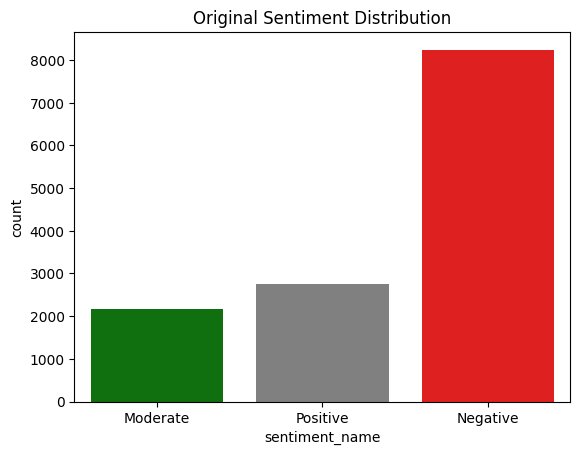

In [ ]:
# Sentiment Distribution
# Load processed_df (has correct Processed_Audio paths)
df_processed = pd.read_csv("DataFrame/processed_df.csv")
df_sentiment = pd.read_csv("DataFrame/combined_grouped.csv")

# Keep only sentiment columns from combined_grouped
df_sentiment = df_sentiment[["gender", "emotion", "emotion_lb", "sentiment"]].drop_duplicates()

# Join sentiment labels to processed audio
# Match by emotion/emotion_lb
df = df_processed.merge(df_sentiment[["emotion", "sentiment"]], on="emotion", how="left")

# Remove rows without sentiment label
df = df.dropna(subset=["sentiment"])
df["sentiment"] = df["sentiment"].astype(int)

# Remove duplicates from merge (same audio file with duplicate emotion entries)
df = df.drop_duplicates(subset=["path"])

# Remap sentiment values from [-1, 0, 1] to [0, 1, 2] for model training
# -1 (Negative) -> 0, 0 (Moderate) -> 1, 1 (Positive) -> 2
df["sentiment"] = df["sentiment"].map({-1: 0, 0: 1, 1: 2}).astype(int)

# Normalize path separators (backslash → forward slash for Linux/Vast.ai compatibility)
df["path"] = df["path"].str.replace("\\", "/", regex=False)

# Map sentiment numbers → names (optional)
label_map = {-1: "Negative", 0: "Moderate", 1: "Positive"}
df["sentiment_name"] = df["sentiment"].map(label_map)

print(f"Loaded {len(df)} samples with sentiment labels")

print(f"Path example: {df['path'].iloc[0]}")plt.show()

print(f"Sentiment distribution:\n{df['sentiment'].value_counts()}")plt.title("Original Sentiment Distribution")

print(df.head())sns.countplot(data=df, x="sentiment_name", palette=["green", "gray", "red"])


In [9]:
# Augmentation Functions

AUG_SAVE_DIR = "Data/Augmented_Sentiment"
os.makedirs(AUG_SAVE_DIR, exist_ok=True)

def aug_noise(audio):
    return audio + np.random.normal(0, 0.005, len(audio))

def aug_gain(audio):
    return audio * np.random.uniform(0.8, 1.2)

def aug_pitch(audio, sr=16000):
    steps = np.random.uniform(-1.5, 1.5)
    return librosa.effects.pitch_shift(audio, sr=sr, n_steps=steps)

AUGS = [aug_noise, aug_gain, aug_pitch]

In [ ]:
#Balance Sentiment Classes with Augmentation

def augment_sentiment(df):
    print("Balancing sentiment distribution with augmentation...")

    counts = df["sentiment"].value_counts()
    target = counts.max()

    print("Before balancing:")
    print(counts)

    new_rows = []

    for sent_value, count in counts.items():
        need = target - count
        print(f"Sentiment {sent_value} requires {need} augmentations")

        if need <= 0:
            continue

        group = df[df["sentiment"] == sent_value]

        for _ in range(need):
            row = group.sample(1).iloc[0]
            # Load .wav file (raw audio)
            audio, sr = librosa.load(row["path"], sr=16000)

            aug_fn = np.random.choice(AUGS)
            audio_aug = aug_fn(audio)

            out_name = f"{sent_value}_AUG_{np.random.randint(999999)}.wav"
            out_path = os.path.join(AUG_SAVE_DIR, out_name)
            sf.write(out_path, audio_aug, sr)

            new_rows.append({
                "path": out_path,
                "sentiment": row["sentiment"],
                "sentiment_name": row["sentiment_name"],
                "dataset": "AUGMENT"
            })

    df_bal = pd.concat([df, pd.DataFrame(new_rows)], ignore_index=True)

    print("\nAfter balancing:")
    print(df_bal["sentiment"].value_counts())

    return df_bal

In [ ]:
# Run balancing
df_balanced = augment_sentiment(df)

print(f"\ndf_balanced shape: {df_balanced.shape}")
print(f"df_balanced samples: {len(df_balanced)}")
if len(df_balanced) == 0:
    print("ERROR: df_balanced is empty!")
    print(f"Original df had {len(df)} samples")
else:
    print(df_balanced.head())

Balancing sentiment distribution with augmentation...
Before balancing:
sentiment
-1    8244
 1    2759
 0    2171
Name: count, dtype: int64
Sentiment -1 requires 0 augmentations
Sentiment 1 requires 5485 augmentations
Sentiment 0 requires 6073 augmentations

After balancing:
sentiment
 0    8244
 1    8244
-1    8244
Name: count, dtype: int64


In [12]:
# Train/Val/Test Split

train_df, test_df = train_test_split(
    df_balanced, test_size=0.15, random_state=42, stratify=df_balanced["sentiment"]
)

train_df, val_df = train_test_split(
    train_df, test_size=0.15, random_state=42, stratify=train_df["sentiment"]
)

print(len(train_df), len(val_df), len(test_df))


17868 3154 3710


In [ ]:
#HF Dataset Conversion
from datasets import Dataset, DatasetDict

def to_hf(df):
    return Dataset.from_pandas(df[["path","sentiment"]])

datasets = DatasetDict({
    "train": to_hf(train_df),
    "validation": to_hf(val_df),
    "test": to_hf(test_df)
})

extractor = AutoFeatureExtractor.from_pretrained("facebook/wav2vec2-base")

def preprocess(batch):
    audio = []
    for p in batch["path"]:
        if p.endswith(".npy"):
            # Load .npy file
            audio.append(np.load(p))
        else:
            # Load .wav file with librosa
            audio.append(librosa.load(p, sr=16000)[0])
    
    x = extractor(audio, sampling_rate=16000, return_tensors="pt", padding=True)
    x["labels"] = batch["sentiment"]
    return x

datasets = datasets.map(
    preprocess,
    remove_columns=["path","sentiment"],
    batched=True,
    batch_size=4
)

datasets = datasets.with_format("torch")

d:\UOG\Study\Computing\Final\Ser\con.env\Lib\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(
Map:  19%|█▉        | 696/3710 [00:05<00:22, 132.52 examples/s]


KeyboardInterrupt: 

In [ ]:
# 7 — Training Wav2Vec2
model = AutoModelForAudioClassification.from_pretrained(
    "facebook/wav2vec2-base",
    num_labels=3,
    label2id={0: 0, 1: 1, 2: 2},  # Maps to: Negative (0), Moderate (1), Positive (2)
    id2label={0: "Negative", 1: "Moderate", 2: "Positive"},
    ignore_mismatched_sizes=True
)

args = TrainingArguments(
    output_dir="Models/Sentiment_W2V2",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    evaluation_strategy="epoch",
    save_strategy="no",          # ← no checkpoints
    logging_strategy="epoch",
    fp16=True
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=datasets["train"],
    eval_dataset=datasets["validation"],
    tokenizer=extractor
)

trainer.train()

trainer.save_model("Models/Sentiment_W2V2/final_model")


In [ ]:
# 8 — Evaluation
import json

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

y_true, y_pred, y_prob = [], [], []

for batch in datasets["test"]:
    inputs = {k: v.unsqueeze(0).to(device) for k, v in batch.items() if k != "labels"}
    label = batch["labels"]

    with torch.no_grad():
        logits = model(**inputs).logits
        prob = torch.softmax(logits, dim=-1).cpu().numpy()[0]
        pred = prob.argmax()

    y_true.append(label)
    y_pred.append(pred)
    y_prob.append(prob)

# ============== METRICS (ROUNDED) ==============
acc = round(accuracy_score(y_true, y_pred), 3)
report = classification_report(y_true, y_pred, labels=[0, 1, 2], target_names=["Negative","Moderate","Positive"], digits=3, output_dict=True)

print("Accuracy:", acc)
print(classification_report(y_true, y_pred, labels=[0, 1, 2], target_names=["Negative","Moderate","Positive"]))

# ============== SAVE METRICS ==============
metrics = {
    "accuracy": acc,
    "precision_negative": round(report["Negative"]["precision"], 3),
    "recall_negative": round(report["Negative"]["recall"], 3),
    "f1_negative": round(report["Negative"]["f1-score"], 3),
    "precision_moderate": round(report["Moderate"]["precision"], 3),
    "recall_moderate": round(report["Moderate"]["recall"], 3),
    "f1_moderate": round(report["Moderate"]["f1-score"], 3),
    "precision_positive": round(report["Positive"]["precision"], 3),
    "recall_positive": round(report["Positive"]["recall"], 3),
    "f1_positive": round(report["Positive"]["f1-score"], 3),
}

with open("Models/Sentiment_W2V2/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

# ============== SAVE CLASSIFICATION REPORT ==============
report_df = pd.DataFrame(report).round(3).T
report_df.to_csv("Models/Sentiment_W2V2/classification_report.csv")

# ============== SAVE CONFUSION MATRIX ==============
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Neg","Mod","Pos"]).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("Models/Sentiment_W2V2/confusion_matrix.png", dpi=200)
plt.show()

print("\nMetrics saved to Models/Sentiment_W2V2/metrics.json")
print("Classification report saved to Models/Sentiment_W2V2/classification_report.csv")
print("Confusion matrix saved to Models/Sentiment_W2V2/confusion_matrix.png")

In [ ]:
log_history = trainer.state.log_history
train_loss = [e["loss"] for e in log_history if "loss" in e]
eval_loss  = [e["eval_loss"] for e in log_history if "eval_loss" in e]

plt.plot(train_loss, label="Train Loss")
plt.plot(eval_loss, label="Val Loss")
plt.legend()
plt.title("Training Curve")
plt.show()

In [ ]:
from sklearn.preprocessing import label_binarize
y_true_bin = label_binarize(y_true, classes=[0,1,2])
y_prob = np.array(y_prob)

plt.figure(figsize=(8,6))
for i, label in enumerate(["Neg","Mod","Pos"]):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} AUC={roc_auc:.2f}")

plt.plot([0,1],[0,1],"k--")
plt.legend()
plt.title("ROC Curves")
plt.show()
